In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve
)

In [2]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

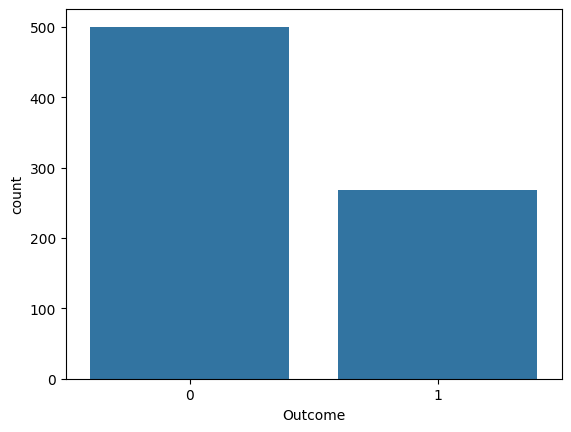

In [7]:
sns.countplot(x="Outcome", data=df)
plt.show()

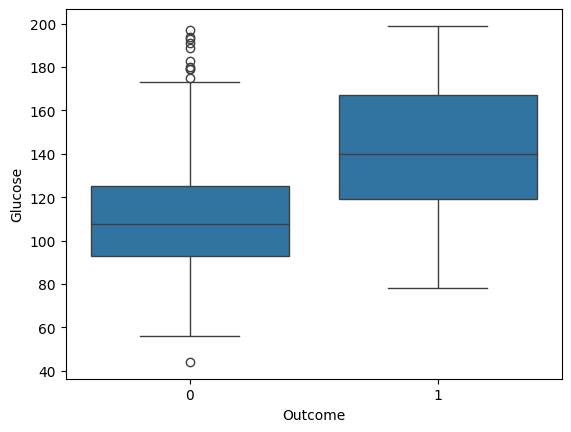

In [8]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

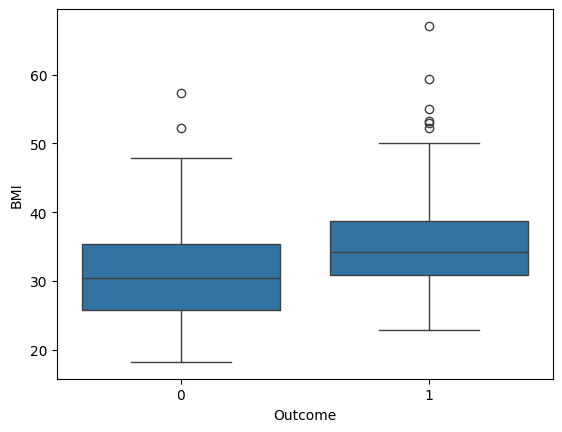

In [9]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.show()

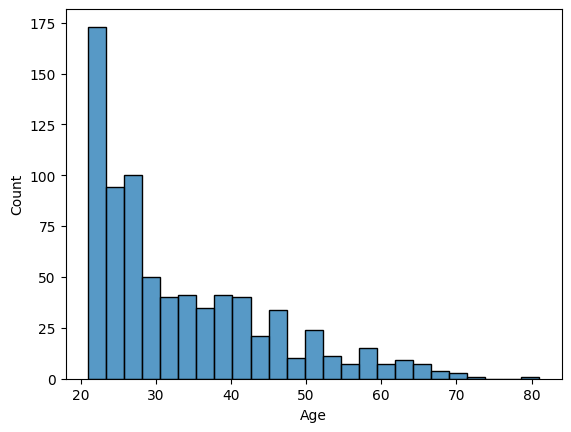

In [10]:
sns.histplot(df["Age"], bins=25)
plt.show()

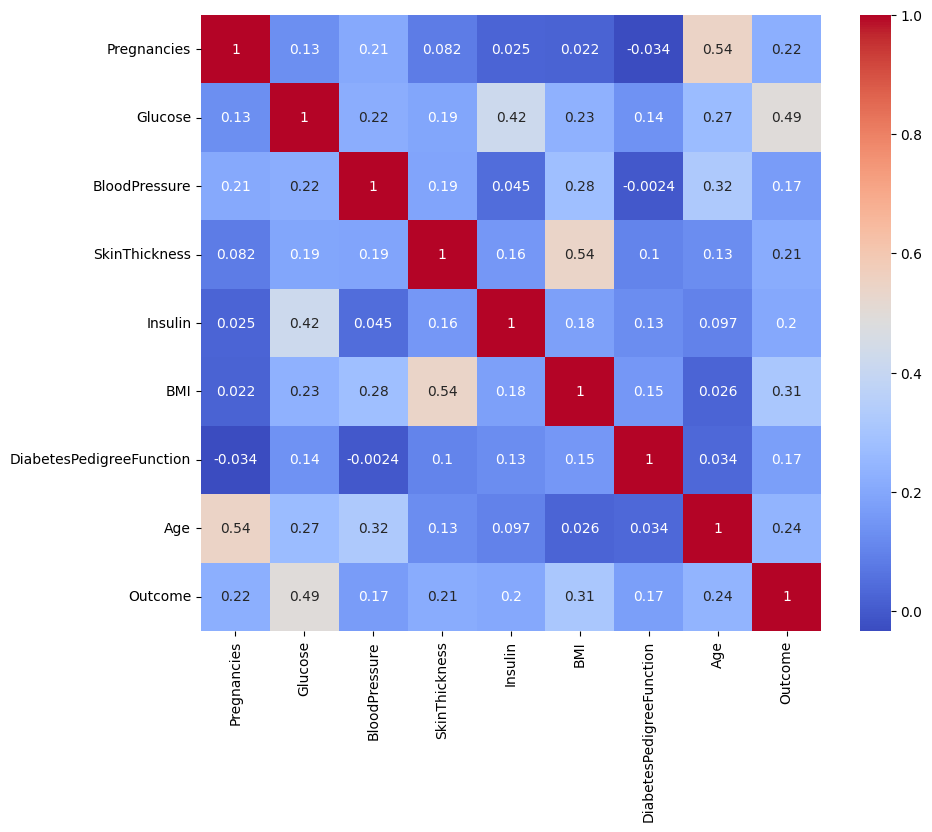

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y
)

In [13]:
lr = LogisticRegression()

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [14]:
rf = RandomForestClassifier(n_estimators=200,random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [15]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [16]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("XGBoost:", accuracy_score(y_test, pred_xgb))

Logistic Regression: 0.7012987012987013
Random Forest: 0.7402597402597403
XGBoost: 0.7727272727272727


In [17]:
print(recall_score(y_test, pred_rf))

0.5555555555555556


In [18]:
print(precision_score(y_test, pred_rf))

0.6521739130434783


In [19]:
print(f1_score(y_test, pred_rf))

0.6


In [20]:
prob = rf.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, prob))

0.8173148148148148


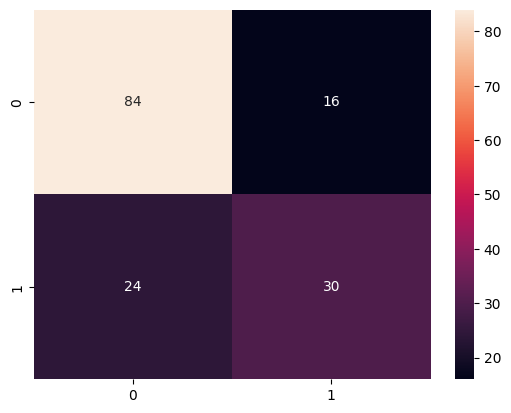

In [21]:
sns.heatmap(confusion_matrix(y_test, pred_rf),
            annot=True,
            fmt="d")

plt.show()

In [22]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



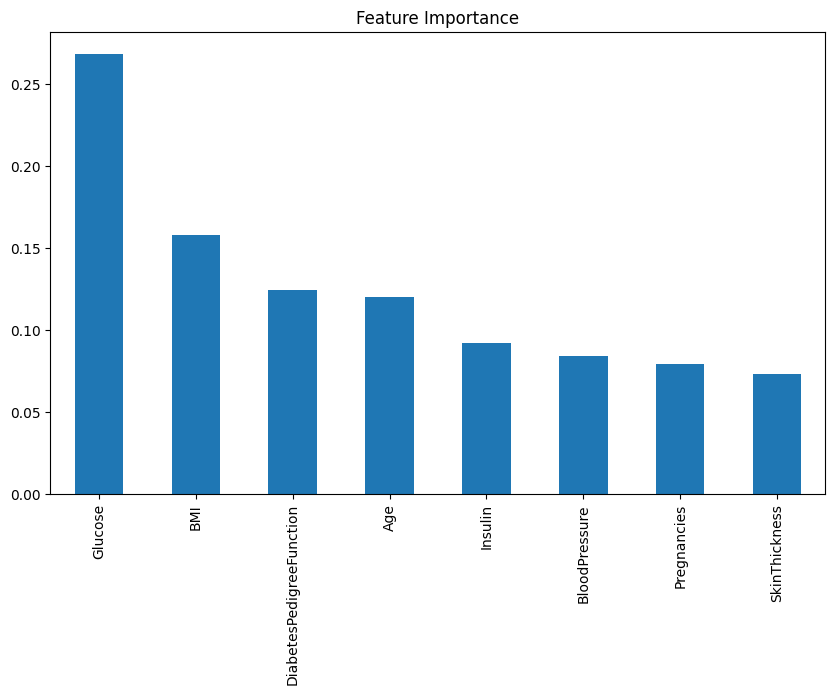

In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.show()

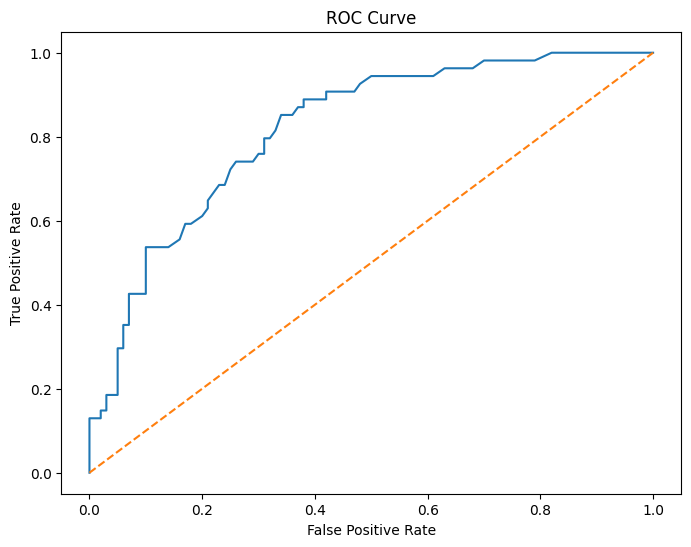

In [24]:
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()